In [1]:
!pip install gdown

In [2]:
import gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import joblib

# Load Dataset

In [3]:
dataset_url = 'https://drive.google.com/uc?id=1xNPSsrSEkdlTA1MoWS04HbtLIxhRFHib'
gdown.download(dataset_url, 'Energy_Production_Dataset.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1xNPSsrSEkdlTA1MoWS04HbtLIxhRFHib
To: /content/Energy_Production_Dataset.csv
100%|██████████| 2.69M/2.69M [00:00<00:00, 163MB/s]


'Energy_Production_Dataset.csv'

In [4]:
df = pd.read_csv("Energy_Production_Dataset.csv")
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


# Data Cleaning

In [6]:
df.isna().sum()

,0
Date,0
Start_Hour,0
End_Hour,0
Source,0
Day_of_Year,0
Day_Name,0
Month_Name,0
Season,0
Production,0


Dataset tidak memiliki missing value

In [7]:
df.duplicated().any()

np.False_

Dataset tidak memiliki data duplikat

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 51864 entries, 0 to 51863
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
51864 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 405.3 KB


Conversi column date dari object menjadi date

In [9]:
df['Source'].value_counts()

,count
Source,
Wind,42484
Solar,9378
Mixed,2


In [10]:
df[df['Source'] == 'Mixed'].head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
30347,2022-06-15,19,20,Mixed,166,Wednesday,June,Summer,2740
49493,2020-04-08,19,20,Mixed,99,Wednesday,April,Spring,734


In [11]:
df = df[df['Source'] != 'Mixed'].copy()

df['Source'].value_counts()

,count
Source,
Wind,42484
Solar,9378


Sumber Mixed di drop karena jumlah yang terlalu kecil dan jika dipertahankan, saat dilakukan chronological split, tidak akan ada yang masuk ke dalam bagian test.

# Exploratory Data Analysis(EDA)

Text(0.5, 1.0, 'Distribusi Production')

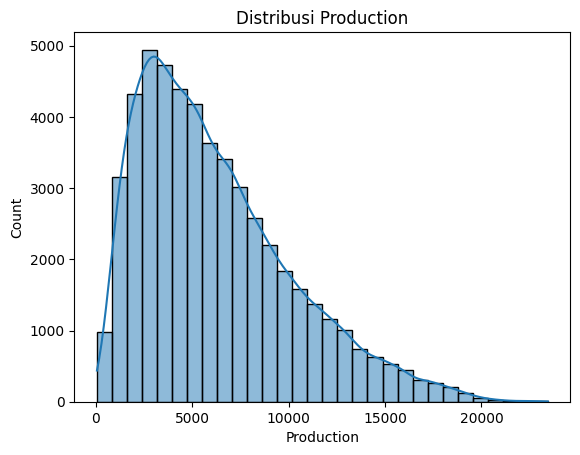

In [12]:
sns.histplot(data = df['Production'], bins = 30, kde = True)
plt.title('Distribusi Production')

Grafik Histogram 'Distribusi Production' menunjukkan bahwa dari dataset terdapat:
*   Skewness Kanan: Distribusi produksi cenderung miring ke kanan atau positively skewed.
*   Puncak Distribusi: Terdapat puncak yang jelas pada rentang produksi sekitar 2000-4000.
*   Jangkauan: Nilai produksi bervariasi dari mendekati 0 hingga lebih dari 20000

Text(0.5, 1.0, 'Distribusi Source')

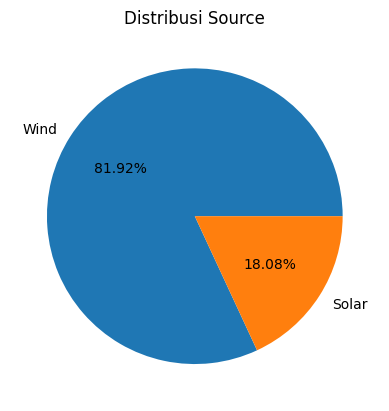

In [13]:
source = df['Source'].value_counts()
plt.pie(source, labels = source.index, autopct = '%2.2f%%')
plt.title('Distribusi Source')

Grafik Pie Chart menunjukkan distribusi sumber produksi didominasi oleh sumber Wind sebesar 81.92%, diikuti oleh sumber Solar sebesar 18.08% dan terakhir sumber Mixed.

Text(0.5, 1.0, 'Production by Source')

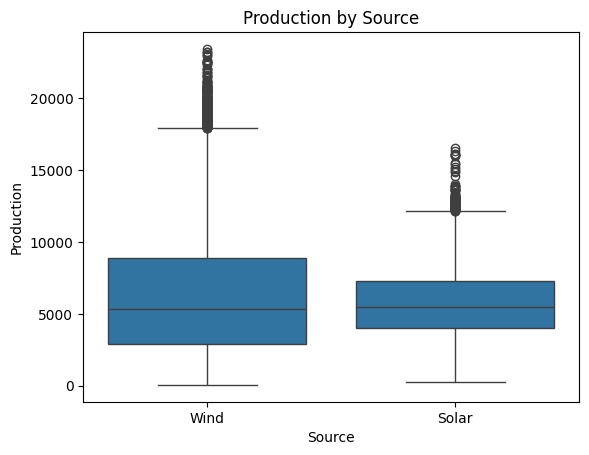

In [14]:
sns.boxplot(x = df['Source'], y = df['Production'])
plt.title('Production by Source')

Grafik Boxplot "Production by Source" menunjukkan bahwa Median produksi sumber Wind lebih tinggi dibanding sumber lainnya, diikuti oleh sumber Solar dan terakhir yang paling kecil berupa sumber Mixed.

Text(0.5, 1.0, 'Production by Start Hour')

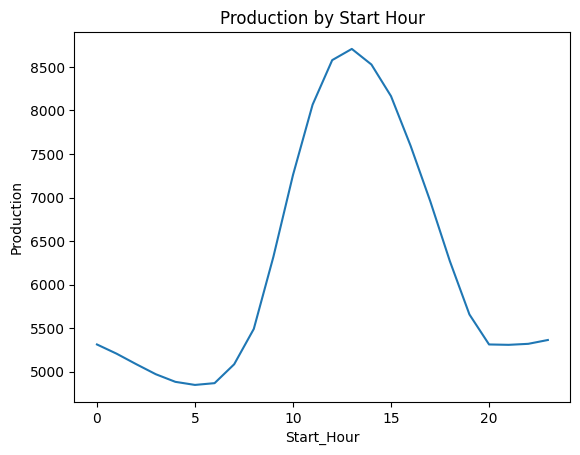

In [15]:
hourly_production = (df.groupby('Start_Hour')['Production'].mean().reset_index())

sns.lineplot(data = hourly_production, x ='Start_Hour', y = 'Production')
plt.title('Production by Start Hour')

Grafik Lineplot "Production by Start Hour" menunjukkan produksi cenderung meningkat pada siang hari, mencapai puncaknya antara start hour 13 dan 15, dlalu mengalami penurunan pada malam hari.

Text(0.5, 1.0, 'Production by Month')

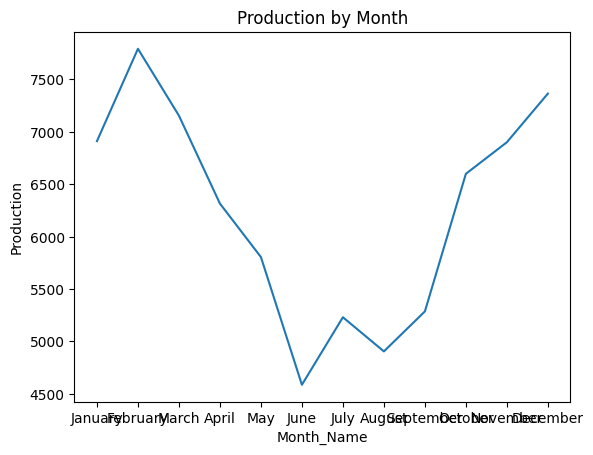

In [16]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_production = (df.groupby('Month_Name')['Production'].mean().reindex(month_order).reset_index())

sns.lineplot(data = monthly_production, x = 'Month_Name', y = 'Production')
plt.title('Production by Month')

Grafik Lineplot "Production by Month" menunjukkan bahwa tingkat produksi umumnya lebih tinggi pada bulan-bulan awal tahun tetapi mencapai pertengahan tahun produksi mulai mengalami penurunan, mencapai akhir tahun produksi mengalami peningkatan lagi.

Text(0.5, 1.0, 'Production by Season')

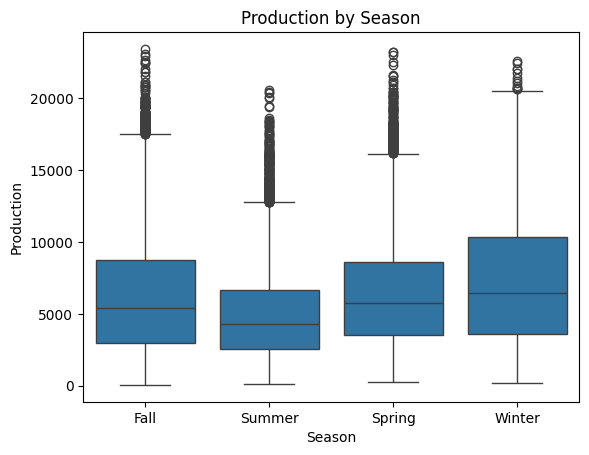

In [17]:
sns.boxplot(x = df['Season'], y = df['Production'])
plt.title('Production by Season')

Grafik Boxplot "Production by Season" menunjukkan bahwa musim gugur dan musim dingin cenderung memiliki rata-rata produksi yang lebih tinggi dibandingkan musim semi dan musim panas.

Text(0.5, 1.0, 'Correlation Heatmap')

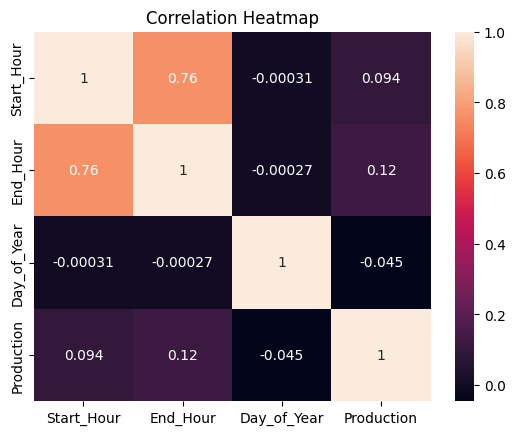

In [18]:
col_number = ['Start_Hour', 'End_Hour', 'Day_of_Year', 'Production']
sns.heatmap(df[col_number].corr(), annot = True)
plt.title('Correlation Heatmap')

Heatmap korelasi menunjukkan terdapat korelasi sangat kuat antara start hour dan end hour. Sedangkan dengan variabel lain korelasi linear terhadap Production relatif rendah. Hal ini mengindikasikan hubungan non-linear dan pola musiman yang tidak dapat dijelaskan hanya dengan korelasi Pearson.

# Chronological Split

In [19]:
df = df.sort_values(by = ['Date', 'Start_Hour', 'Source'])
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
51857,2020-01-01,0,1,Wind,1,Wednesday,January,Winter,3542
51856,2020-01-01,1,2,Wind,1,Wednesday,January,Winter,2932
51847,2020-01-01,2,3,Wind,1,Wednesday,January,Winter,2725
51858,2020-01-01,3,4,Wind,1,Wednesday,January,Winter,2761
51859,2020-01-01,4,5,Wind,1,Wednesday,January,Winter,2708


In [20]:
train_df = df[df['Date'].dt.year <= 2024].copy()
test_df = df[df['Date'].dt.year == 2025].copy()

# Target Creation

In [21]:
q33 = train_df['Production'].quantile(0.33)
q67 = train_df['Production'].quantile(0.67)

q33 dan q67 dipilih agar distribusi antar ketiga kelas relatif seimbang sehingga setiap kategori memiliki representasi data yang cukup. Dimana low merupakan produksi 33% terendah dari data, medium antara 33% dan 67% dari produksi dan high 67% teratas produksi dari data.

In [22]:
def category_production(prod):
    if prod <= q33: return 'Low'
    elif prod <= q67: return 'Medium'
    else: return 'High'

In [23]:
train_df['Production_Category'] = (train_df['Production'].apply(category_production))
test_df['Production_Category'] = (test_df['Production'].apply(category_production))
df['Production_Category'] = (df['Production'].apply(category_production))

Production dikategorikan menjadi Low, Medium, dan High dengan low berupa <= quartile 33%, Medium berupa <= quartile 67% dan High berupa > quartile 67%

Text(0.5, 1.0, 'Distribusi Production Category')

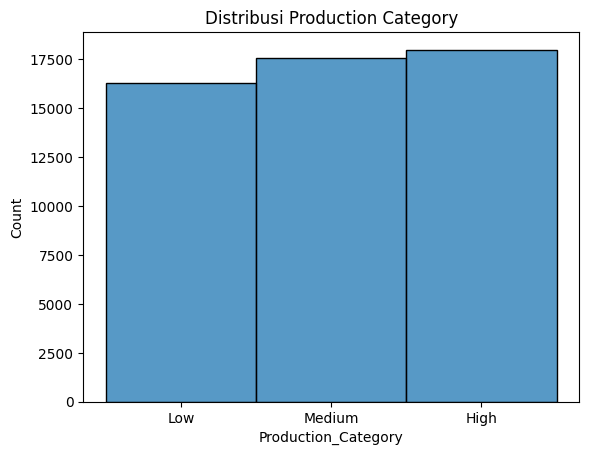

In [24]:
sns.histplot(data = df['Production_Category'])
plt.title('Distribusi Production Category')

In [25]:
print("Distribusi data train:")
print(train_df['Production_Category'].value_counts(normalize=True))

print("\nDistribusi data test:")
print(test_df['Production_Category'].value_counts(normalize=True))

Distribusi data train:
Production_Category
Medium    0.339871
Low       0.330156
High      0.329973
Name: proportion, dtype: float64

Distribusi data test:
Production_Category
High      0.441118
Medium    0.333832
Low       0.225050
Name: proportion, dtype: float64


Distribusi kelas pada data training  relatif seimbang karena kategori Low, Medium, dan High dibentuk menggunakan batas quantile 33% dan 67%.

Pada data testing, distribusi kelas berubah dengan proporsi kelas High meningkat menjadi 44,1% dan kelas Low menurun menjadi 22,5%. Hal ini menunjukkan adanya pergeseran distribusi antara periode training dan testing.

Perbedaan distribusi ini membuat evaluasi menjadi lebih realistis karena model diuji pada kondisi masa depan yang tidak identik dengan data historis yang digunakan untuk pelatihan.

In [26]:
mapping = {'Low': 0, 'Medium': 1, 'High': 2}

train_df['Production_Category_Encoded'] = (train_df['Production_Category'].map(mapping))
test_df['Production_Category_Encoded'] = (test_df['Production_Category'].map(mapping))

Encoding category production dnegan Low = 0, Medium = 1, dan High = 2

# Feature Engineering

In [27]:
for dataset in [train_df, test_df]:
    dataset['Month_Number'] = dataset['Date'].dt.month
    dataset['Day_Of_Week'] = dataset['Date'].dt.dayofweek

    dataset['Hour_Sin'] = np.sin(2*np.pi*dataset['Start_Hour']/24)
    dataset['Hour_Cos'] = np.cos(2*np.pi*dataset['Start_Hour']/24)

    dataset['Day_Of_Year_Sin'] = np.sin(2*np.pi*dataset['Day_of_Year']/366)
    dataset['Day_Of_Year_Cos'] = np.cos(2*np.pi*dataset['Day_of_Year']/366)

# Feature Selection

In [28]:
feature_column = ['Hour_Sin','Hour_Cos','Day_Of_Year_Sin','Day_Of_Year_Cos','Month_Number','Day_Of_Week','Season','Source']

X_train = train_df[feature_column]
X_test = test_df[feature_column]

y_train = train_df['Production_Category_Encoded']
y_test = test_df['Production_Category_Encoded']

# Preprocessing

In [29]:
numerical = ['Hour_Sin', 'Hour_Cos', 'Day_Of_Year_Sin', 'Day_Of_Year_Cos', 'Month_Number', 'Day_Of_Week']
categorical = ['Season', 'Source']

In [30]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])

# Membangun Pipeline

In [31]:
LR_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter = 1000, random_state = 42))])
RF_pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(n_estimators=200, max_depth=10, random_state = 42))])
XGB_pipeline = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(n_estimators=200, max_depth = 6, learning_rate = 0.05, random_state = 42))])

# Training

In [32]:
models = {
    'Logistic Regression': LR_pipeline,
    'Random Forest': RF_pipeline,
    'XGBoost': XGB_pipeline
}

In [33]:
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average = 'macro')

  print(f"Accuracy Model {name}: {accuracy * 100:.2f}%")
  print(f"F1 Score Model {name}: {f1 * 100:.2f}%\n")

Accuracy Model Logistic Regression: 46.46%
F1 Score Model Logistic Regression: 45.64%

Accuracy Model Random Forest: 46.15%
F1 Score Model Random Forest: 45.35%

Accuracy Model XGBoost: 42.70%
F1 Score Model XGBoost: 42.27%



# Additional Analysis

In [34]:
param_grid_RF = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

tscv = TimeSeriesSplit(n_splits=5)
grid_search_RF = GridSearchCV(RF_pipeline, param_grid_RF, cv=tscv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search_RF.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {grid_search_RF.best_params_}")
print(f"Best F1-macro score for Random Forest: {grid_search_RF.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters for Random Forest: {'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best F1-macro score for Random Forest: 0.4839


In [35]:
param_grid_XGB = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=5)
grid_search_XGB = GridSearchCV(XGB_pipeline, param_grid_XGB, cv=tscv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search_XGB.fit(X_train, y_train)

print(f"Best parameters forXGBoost: {grid_search_XGB.best_params_}")
print(f"Best F1-macro score for XGBoost: {grid_search_XGB.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters forXGBoost: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best F1-macro score for XGBoost: 0.4843


In [36]:
RF_pipeline_tuned = Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(
    n_estimators = 300,
    max_depth=5,
    min_samples_leaf = 4,
    min_samples_split = 10,
    random_state = 42
    ))])

XGB_pipeline_tuned = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(
    n_estimators = 200,
    max_depth = 3,
    learning_rate = 0.05,
    subsample = 0.8,
    random_state = 42
    ))])

In [37]:
models = {
    'Logistic Regression': LR_pipeline,
    'Random Forest': RF_pipeline_tuned,
    'XGBoost': XGB_pipeline_tuned
}

In [38]:
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average = 'macro')

  print(f"Accuracy Model {name}: {accuracy * 100:.2f}%")
  print(f"F1 Score Model {name}: {f1 * 100:.2f}%\n")

Accuracy Model Logistic Regression: 46.46%
F1 Score Model Logistic Regression: 45.64%

Accuracy Model Random Forest: 44.04%
F1 Score Model Random Forest: 42.87%

Accuracy Model XGBoost: 44.21%
F1 Score Model XGBoost: 43.48%



Berdasarkan hasil Accuracy dan F1 Score maka Logistic Regression dipilih sebagai model utama

# Evaluasi

In [39]:
Dummy = DummyClassifier(strategy = 'most_frequent')

Dummy.fit(X_train, y_train)
y_pred_dummy = Dummy.predict(X_test)

print(f"Accuracy test dummy: {accuracy_score(y_test, y_pred_dummy) * 100:.2f}%")
print(f"F1 Score test dummy: {f1_score(y_test, y_pred_dummy, average='macro') * 100:.2f}%")

Accuracy test dummy: 33.38%
F1 Score test dummy: 16.69%


Walaupun accuracy dari Logisitc Regression berada pada 46.46%, jika dibandingkan dengan sebuah test dummy atau menjawab hanya dengan yg paling sering muncul yang menghasilkan accuracy 33.38%. Logistic Regression menunjukkan persentase accuracy sebesar 13.08%, hal ini menunjukkan walaupun accuracy rendah model tetap mempelajari pola dari dataset

In [40]:
y_pred_LR = LR_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_LR, target_names=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.37      0.72      0.49      1804
      Medium       0.43      0.30      0.36      2676
        High       0.62      0.45      0.53      3536

    accuracy                           0.46      8016
   macro avg       0.47      0.49      0.46      8016
weighted avg       0.50      0.46      0.46      8016



Text(0.5, 1.0, 'Confusion Matrix')

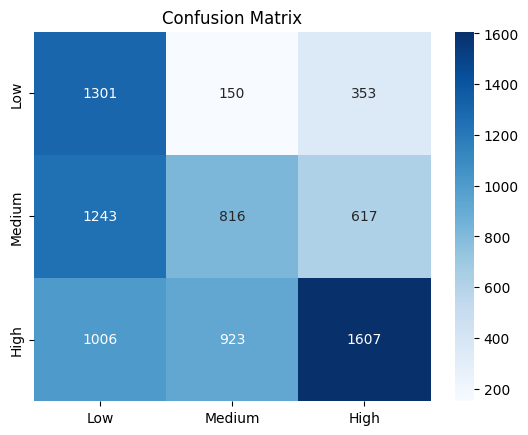

In [41]:
cm = confusion_matrix(y_test, y_pred_LR)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix')

# Export Model

In [42]:
final_model = LR_pipeline
final_model.fit(X_train, y_train)

joblib.dump(final_model, "energy_level_pipeline.pkl")

['energy_level_pipeline.pkl']

In [43]:
y_pred = final_model.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred)
macro_f1_final = f1_score(y_test, y_pred, average='macro')

print(accuracy_final)
print(macro_f1_final)

0.46457085828343314
0.45641976122983224


In [44]:
metadata = {
    "model_name": "Logistic Regression",
    "accuracy": accuracy_final,
    "macro_f1": macro_f1_final,
    "chronological_split": "Train: 2021-2024 | Test: 2025",
    "source_values": ['Solar','Wind'],
    "min_date": str(df['Date'].min()),
    "max_date": str(df['Date'].max())
}

joblib.dump(metadata, "model_metadata.pkl")

['model_metadata.pkl']